In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces /content/

In [3]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Dependencies and Imports...

In [4]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.7 MB/s eta 0:00:00


In [5]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Reproducibility...

In [6]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


Configurations...

In [8]:
[x for x in timm.list_models() if 'xception' in x]

['legacy_xception',
 'xception41',
 'xception41p',
 'xception65',
 'xception65p',
 'xception71']

In [9]:
model_name = 'xception65'

image_size = 299
batch_size = 32

learning_rate = 5e-5
weight_decay = 1e-4

maximum_epochs = 20
patience = 5

Dataset Path...

In [10]:
# root = '/content/drive/MyDrive/DL_Project/datasets'

# ffpp_root = os.path.join(root, 'ffpp_cropped_faces')

# celeb_root = os.path.join(root, 'celebv2_cropped_faces')

ffpp_root = '/content/ffpp_cropped_faces'

celeb_root = '/content/celebv2_cropped_faces'

Dataset Staistics...

In [11]:
def count_images(folder):

    real = len(os.listdir(os.path.join(folder,'real')))
    fake = len(os.listdir(os.path.join(folder,'fake')))

    return real, fake

In [12]:
for split in ['train','val','test']:
    real,fake = count_images(os.path.join(ffpp_root, split))

    print('\n', split,':', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


 train : real = 7500 | fake = 6869 | total = 14369

 val : real = 1250 | fake = 1130 | total = 2380

 test : real = 1250 | fake = 1138 | total = 2388


In [13]:
real,fake = count_images(celeb_root)

print('\nceleb-df :', 'real =', real, '|', 'fake =', fake, '|', 'total =', real+fake)


celeb-df : real = 2999 | fake = 2991 | total = 5990


JPEG Compression Transform...

In [14]:
from PIL import Image
import io

class RandomJPEGCompression:

    def __init__(self, p=0.5, qualities=(90, 70, 50, 30, 10)):

        self.p = p
        self.qualities = qualities

    def __call__(self, img):

        if random.random() > self.p:
            return img

        quality = random.choice(self.qualities)

        # compress, then decompress in memory..
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)

        img = Image.open(buffer).convert('RGB')

        return img

Dataset Class...

In [15]:
class DeepfakeDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.transform = transform
        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in os.listdir(real_dir):
            self.samples.append((os.path.join(real_dir,img), 0))

        for img in os.listdir(fake_dir):
            self.samples.append((os.path.join(fake_dir,img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):

        path,label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label,dtype=torch.float32)

Transforms...

In [16]:
imagenet_mean = [0.485,0.456,0.406]
imagenet_std = [0.229,0.224,0.225]

In [17]:
train_transform = transforms.Compose([transforms.Resize((image_size, image_size)),
                                      transforms.RandomHorizontalFlip(), transforms.ColorJitter(brightness=0.1, contrast=0.1),
                                      # compression-aware trianing..
                                      RandomJPEGCompression(p=0.5,qualities=(90, 70, 50, 30, 10)), transforms.ToTensor(),
                                      transforms.Normalize(imagenet_mean, imagenet_std)])

In [18]:
test_transform = transforms.Compose([transforms.Resize((image_size,image_size)),
                                     transforms.ToTensor(),
                                     transforms.Normalize(imagenet_mean, imagenet_std)])

Dataloaders...

In [19]:
train_ds = DeepfakeDataset(os.path.join(ffpp_root, 'train'), train_transform)

val_ds = DeepfakeDataset(os.path.join(ffpp_root, 'val'), test_transform)

test_ds = DeepfakeDataset(os.path.join(ffpp_root, 'test'), test_transform)

celeb_ds = DeepfakeDataset(celeb_root, test_transform)

In [20]:
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

celeb_loader = DataLoader(celeb_ds, batch_size=batch_size, shuffle=False, pin_memory=True)

In [21]:
print('\nlength of train ffpp :', len(train_ds))
print('\nlength of val ffpp :', len(val_ds))
print('\nlength of test ffpp :', len(test_ds))
print('\nlength of celeb :', len(celeb_ds))


length of train ffpp : 14369

length of val ffpp : 2380

length of test ffpp : 2388

length of celeb : 5990


In [22]:
next(iter(train_loader))[0].shape

torch.Size([32, 3, 299, 299])

Verify CAT Augmentation...

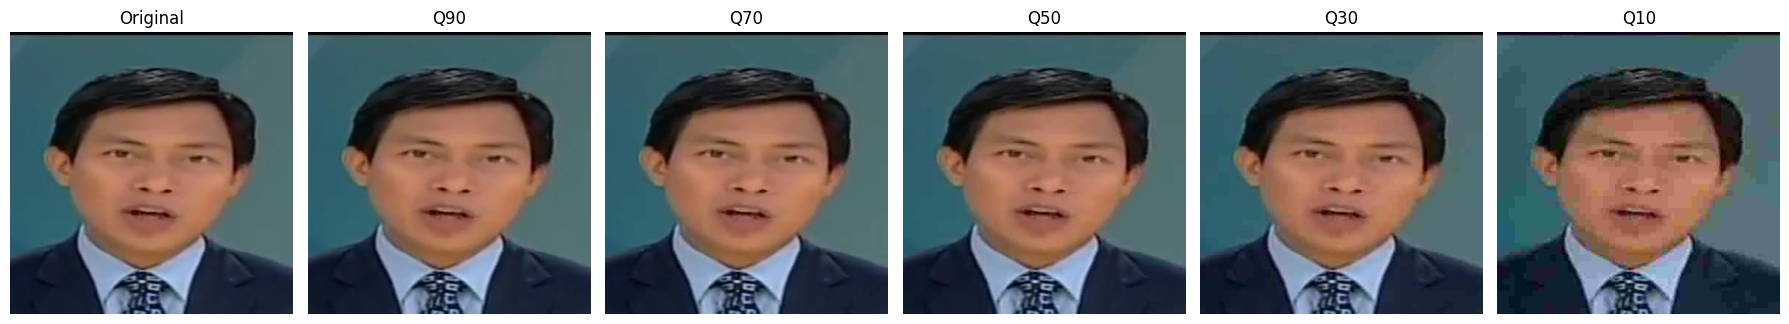

In [23]:
# load one original image..
img_path = train_ds.samples[1][0]
img = Image.open(img_path).convert('RGB')

qualities = [100,90, 70, 50,30, 10]
fig, axes = plt.subplots(1, len(qualities), figsize=(18, 4))

for ax, q in zip(axes, qualities):

    if q == 100:
        out = img
        title = 'Original'
    else:
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=q)
        buffer.seek(0)
        out = Image.open(buffer).convert('RGB')
        title = f'Q{q}'

    ax.imshow(out)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

Model...

In [24]:
model = timm.create_model(model_name, pretrained=True, num_classes=1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/160M [00:00<?, ?B/s]

In [25]:
print(model.get_classifier())

Linear(in_features=2048, out_features=1, bias=True)


In [26]:
total_parameters = sum(p.numel() for p in model.parameters())

print(f'\nparameters: {total_parameters:,}')


parameters: 37,869,361


Loss / Optimizer ...

In [27]:
criterion = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [28]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

AMP...

In [29]:
scaler = torch.amp.GradScaler('cuda')

Evaluation Function...

In [30]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        labels = labels.float().view_as(outputs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    auc = roc_auc_score(all_labels, all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

Training Loop...

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'val_auc': [],
           'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': []}

best_auc = 0.0
patience_counter = 0

save_dir = '/content/drive/MyDrive/DL_Project/checkpoints'
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir,'best_cat_xception.pth')

In [ ]:
for epoch in range(maximum_epochs):

    print(f'\nepoch [{epoch+1}/{maximum_epochs}]')

    # training...

    model.train()

    running_loss = 0.0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).float()

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            outputs = model(images).squeeze(1)
            labels = labels.view_as(outputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f'{loss.item():.3f}')

    train_loss = running_loss/len(train_loader.dataset)

    # validation..

    val_metrics = evaluate(model, val_loader, criterion)

    val_loss = val_metrics['loss']
    val_auc = val_metrics['auc']

    val_acc = val_metrics['accuracy']
    val_precision = val_metrics['precision']
    val_recall = val_metrics['recall']
    val_f1 = val_metrics['f1']

    scheduler.step(val_auc)

    history['train_loss'].append(train_loss)

    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    print(f'\ntrain loss  : {train_loss:.4f}')

    print(f'\nval loss  : {val_loss:.4f}')
    print(f'\nval auc  : {val_auc:.4f}')

    print(f'\nval accuracy  : {val_acc:.4f}')
    print(f'val precision  : {val_precision:.4f}')
    print(f'val recall  : {val_recall:.4f}')
    print(f'val f1  : {val_f1:.4f}')

    # early stopping..

    if val_auc > best_auc:
        best_auc = val_auc
        patience_counter = 0

        torch.save({'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_auc': best_auc},best_model_path)

        print(f'\nbest model saved (auc={best_auc:.4f})')

    else:
        patience_counter += 1
        print(f'\nno improvement ({patience_counter}/{patience})')

    if patience_counter >= patience:
        print('\nearly stopping triggered...')

        break


epoch [1/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.5023

val loss  : 3.1105

val auc  : 0.8909

val accuracy  : 0.8324
val precision  : 0.8232
val recall  : 0.8239
val f1  : 0.8235

best model saved (auc=0.8909)

epoch [2/20]


  0%|          | 0/450 [00:00<?, ?it/s]

...

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0450

val loss  : 1.4805

val auc  : 0.9499

val accuracy  : 0.8924
val precision  : 0.8666
val recall  : 0.9142
val f1  : 0.8898

no improvement (4/5)

epoch [17/20]


  0%|          | 0/450 [00:00<?, ?it/s]

  0%|          | 0/75 [00:00<?, ?it/s]


train loss  : 0.0450

val loss  : 2.5677

val auc  : 0.9335

val accuracy  : 0.8769
val precision  : 0.8416
val recall  : 0.9124
val f1  : 0.8756

no improvement (5/5)

early stopping triggered...


In [ ]:
history_df = pd.DataFrame(history)

results_dir = '/content/drive/MyDrive/DL_Project/results/cat_xception/'

os.makedirs(results_dir, exist_ok=True)
history_df.to_csv(os.path.join(results_dir, 'cat_xception_training_history.csv'), index=False)

print('training history saved...')

training history saved...


Load Model Checkpoint...

In [31]:
checkpoint_path = '/content/drive/MyDrive/DL_Project/checkpoints/best_cat_xception.pth'

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

print(f'best epoch : {checkpoint['epoch']}')
print(f'best auc   : {checkpoint['best_auc']:.4f}')

best epoch : 12
best auc   : 0.9593


In [32]:
print(len(test_loader.dataset))
print(len(celeb_loader.dataset))

2388
5990


Learning Curves...

In [33]:
history_df = pd.read_csv('/content/drive/MyDrive/DL_Project/results/cat_xception/cat_xception_training_history.csv')

In [34]:
history_df['epoch'] = range(1,len(history_df) + 1)
history_df.head()

,train_loss,val_loss,val_auc,val_acc,val_precision,val_recall,val_f1,epoch
0,0.502347,3.110534,0.890873,0.832353,0.823165,0.823894,0.823529,1
1,0.274507,20.515271,0.883072,0.845378,0.845735,0.824779,0.835125,2
2,0.205268,50.350641,0.893599,0.842017,0.924550,0.726549,0.813677,3
3,0.167705,32.570796,0.905982,0.875210,0.881760,0.851327,0.866276,4
4,0.147256,0.969524,0.933333,0.870168,0.844668,0.890265,0.866868,5


In [35]:
output_dir = '/content/drive/MyDrive/DL_Project/results/cat_xception/'
os.makedirs(output_dir, exist_ok=True)

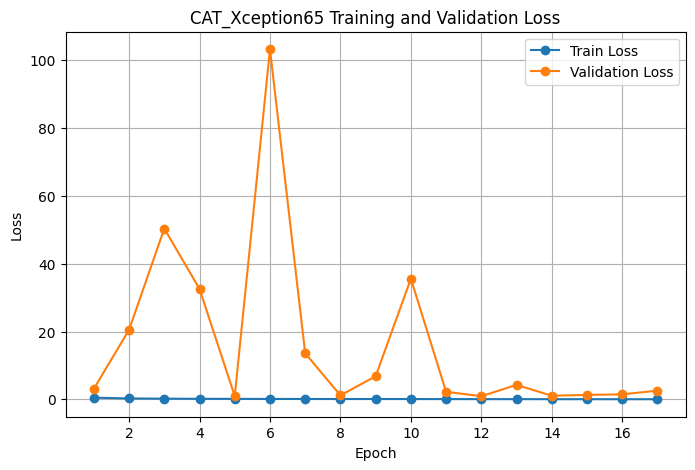

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')

plt.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CAT_Xception65 Training and Validation Loss')

plt.legend()
plt.grid(True)

save_path = os.path.join(output_dir, 'cat_xception65_loss_plot.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

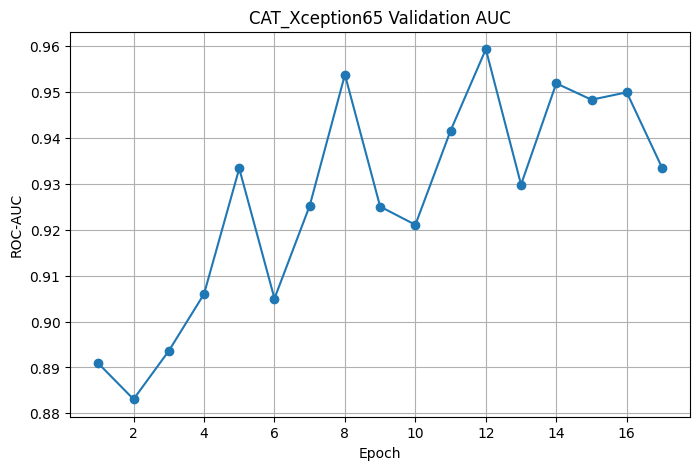

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')

plt.xlabel('Epoch')
plt.ylabel('ROC-AUC')
plt.title('CAT_Xception65 Validation AUC')

plt.grid(True)

save_path = os.path.join(output_dir, 'cat_xception65_auc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

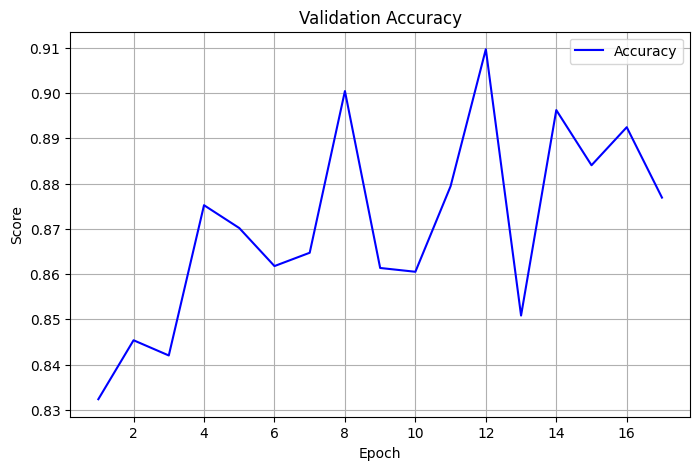

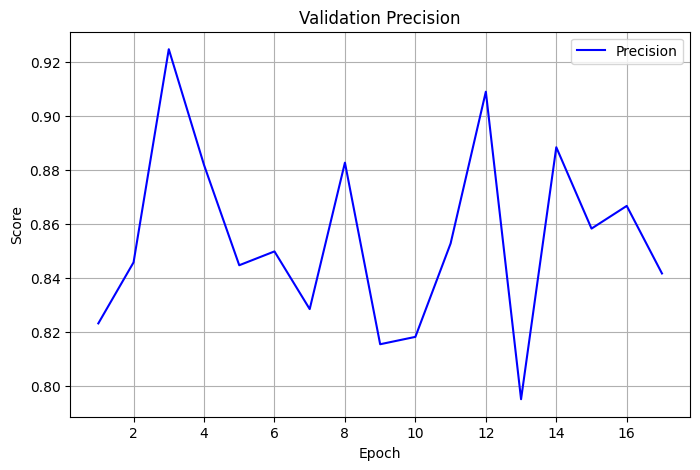

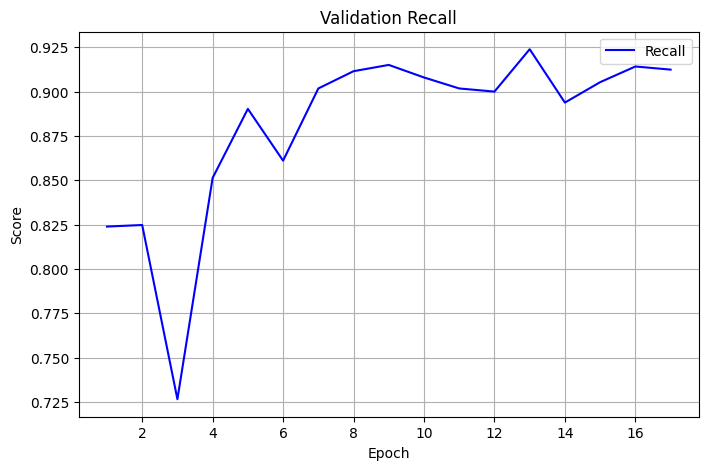

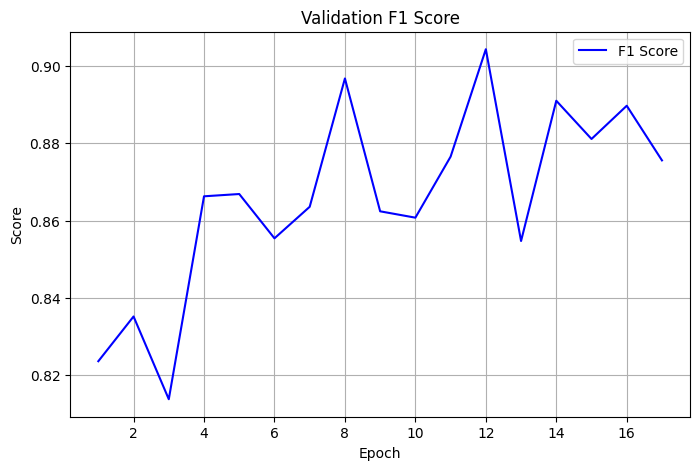

In [38]:
metrics = ['val_acc', 'val_precision', 'val_recall', 'val_f1']
display_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric, name in zip(metrics, display_names):
    plt.figure(figsize=(8,5))

    plt.plot(history_df['epoch'], history_df[metric], label=name, color='blue')

    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title(f'Validation {name}')

    plt.legend()
    plt.grid(True)

    file_name = f'cat_xception65_{metric}.pdf'
    save_path = os.path.join(output_dir, file_name)
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

FF++ Evaluation...

In [ ]:
ffpp_metrics = evaluate(model, test_loader, criterion)

print('\nfaceforensics++ test results')

print(f'AUC  : {ffpp_metrics['auc']:.4f}')
print(f'Accuracy  : {ffpp_metrics['accuracy']:.4f}')
print(f'Precision  : {ffpp_metrics['precision']:.4f}')
print(f'Recall  : {ffpp_metrics['recall']:.4f}')
print(f'F1  : {ffpp_metrics['f1']:.4f}')

  0%|          | 0/75 [00:00<?, ?it/s]


faceforensics++ test results
AUC  : 0.9452
Accuracy  : 0.8777
Precision  : 0.8770
Recall  : 0.8647
F1  : 0.8708


FF++ ROC Curve...

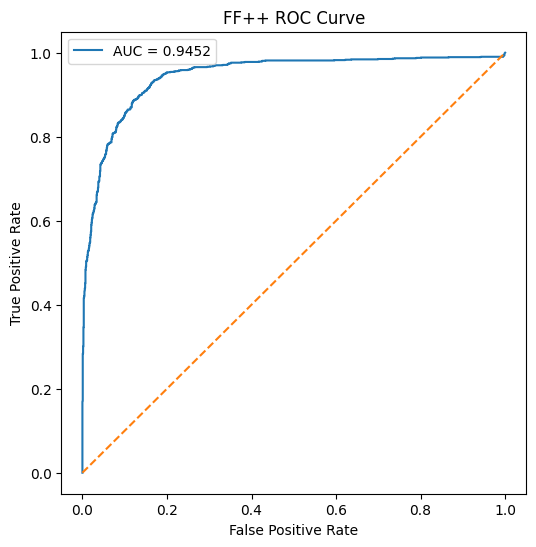

In [ ]:
fpr, tpr, _ = roc_curve(ffpp_metrics['labels'], ffpp_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {ffpp_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('FF++ ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'cat_xception65_ffpp_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

FF++ Confusion Matrix...

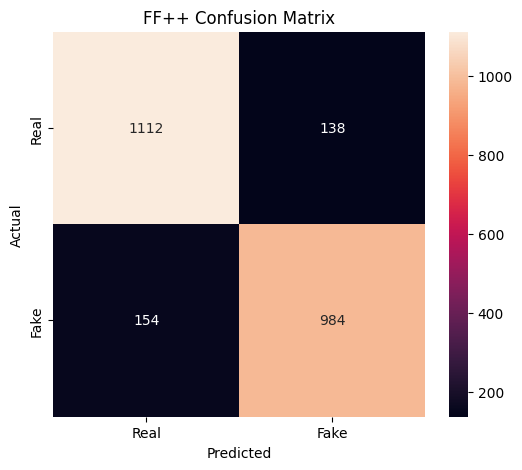

In [ ]:
import seaborn as sns

cm = confusion_matrix(ffpp_metrics['labels'], ffpp_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('FF++ Confusion Matrix')

save_path = os.path.join(output_dir, 'cat_xception65_ffpp_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Evaluation...

In [ ]:
celeb_metrics = evaluate(model, celeb_loader, criterion)

print('\ncelebv2 evaluation results')

print(f'AUC  : {celeb_metrics['auc']:.4f}')
print(f'Accuracy  : {celeb_metrics['accuracy']:.4f}')
print(f'Precision  : {celeb_metrics['precision']:.4f}')
print(f'Recall  : {celeb_metrics['recall']:.4f}')
print(f'F1  : {celeb_metrics['f1']:.4f}')

  0%|          | 0/188 [00:00<?, ?it/s]


celebv2 evaluation results
AUC  : 0.8039
Accuracy  : 0.6770
Precision  : 0.6143
Recall  : 0.9488
F1  : 0.7458


CelebV2 ROC Curve...

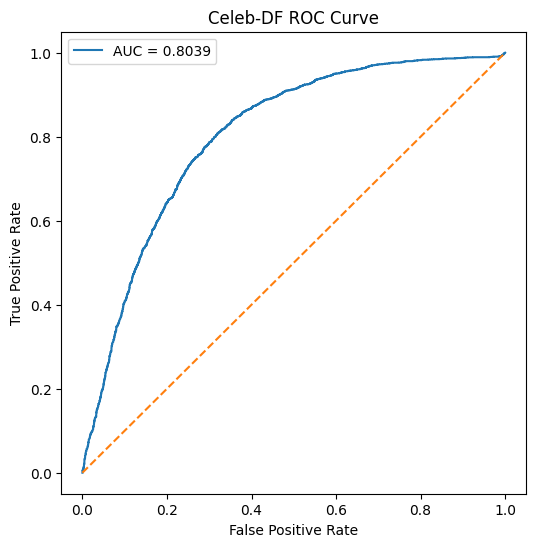

In [ ]:
fpr, tpr, _ = roc_curve(celeb_metrics['labels'], celeb_metrics['probs'])

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'AUC = {celeb_metrics['auc']:.4f}')

plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Celeb-DF ROC Curve')

plt.legend()

save_path = os.path.join(output_dir, 'cat_xception65_celebv2_roc_curve.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

CelebV2 Confusion Matrix...

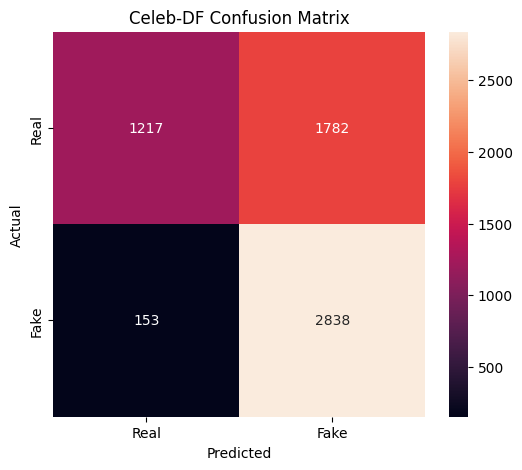

In [ ]:
cm = confusion_matrix(celeb_metrics['labels'], celeb_metrics['preds'])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Celeb-DF Confusion Matrix')

save_path = os.path.join(output_dir, 'cat_xception65_celebv2_confusion_matrix.pdf')
plt.savefig(save_path, bbox_inches='tight')

plt.show()

Generalization Gap...

In [ ]:
generalization_gap = (ffpp_metrics['auc'] - celeb_metrics['auc'])

print('\ngeneralization gap')

print(f'FF++ AUC  : {ffpp_metrics['auc']:.4f}')

print(f'CelebDF AUC  : {celeb_metrics['auc']:.4f}')

print(f'Gap  : {generalization_gap:.4f}')


generalization gap
FF++ AUC  : 0.9452
CelebDF AUC  : 0.8039
Gap  : 0.1412


Final Results Table...

In [ ]:
results_df = pd.DataFrame([

    {
        'Dataset':'FF++ Test',

        'AUC':ffpp_metrics['auc'],
        'Accuracy':ffpp_metrics['accuracy'],
        'Precision':ffpp_metrics['precision'],
        'Recall':ffpp_metrics['recall'],
        'F1':ffpp_metrics['f1']
    },

    {
        'Dataset':'CelebDF',

        'AUC':celeb_metrics['auc'],
        'Accuracy':celeb_metrics['accuracy'],
        'Precision':celeb_metrics['precision'],
        'Recall':celeb_metrics['recall'],
        'F1':celeb_metrics['f1']
    }
])

results_df

,Dataset,AUC,Accuracy,Precision,Recall,F1
0,FF++ Test,0.945185,0.877722,0.877005,0.864675,0.870796
1,CelebDF,0.803947,0.676962,0.614286,0.948847,0.745763


In [ ]:
results_dir = '/content/drive/MyDrive/DL_Project/results/cat_xception/'

os.makedirs(results_dir, exist_ok=True)

results_df.to_csv(os.path.join(results_dir, 'cat_xception65_results.csv'), index=False)

print('results saved.')

results saved.
